# Welcome to the Entity Linking Laboratory!

This notebook demonstrates how unknown objects can be linked to known concepts using a Vision-Language Model (VLM) and a domain ontology. The pipeline is modular, making it easy to integrate new models and ontologies.

In this example, we use the GroundingDino VLM to detect objects and create bounding boxes. At this stage, the objects are unclassified, meaning they have no semantic labels. We then run a second VLM — the CLIP classifier — using each bounding box as image input. The classifier’s vocabulary comes from the domain ontology. In our case, the “meals” ontology contains various food items enriched with semantic information.

For each detected object, we create a new FoodConcept class instance containing attributes such as the object’s name, bounding box, and a list of all relations linked to it. For example, the object apple is related to the concept cutting, meaning it can be cut into pieces. The cutting process is defined in the domain ontology as a sequence of steps that can be executed by the user.

The user can also request an explanation of any detected object, which provides a detailed description of the object and its relations. Such explanations may include information about the object itself, how it can be cut, and the steps needed to prepare it for eating.

In [2]:
import sys
import os
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(project_root)
import src.entity_linking_lab.utils.pipeline as pipeline
import src.entity_linking_lab.utils.detection_concepts as det_src
# Define image path (relative to project root)
img_path = os.path.join(project_root, "resources", "images", "FruitsOnTable_nearView_v3.png")

* Owlready2 * Running Pellet...
    java -Xmx2000M -cp /home/sorin/dev/entity_linking_lab/.venv/lib/python3.12/site-packages/owlready2/pellet/antlr-runtime-3.2.jar:/home/sorin/dev/entity_linking_lab/.venv/lib/python3.12/site-packages/owlready2/pellet/jcl-over-slf4j-1.6.4.jar:/home/sorin/dev/entity_linking_lab/.venv/lib/python3.12/site-packages/owlready2/pellet/xml-apis-1.4.01.jar:/home/sorin/dev/entity_linking_lab/.venv/lib/python3.12/site-packages/owlready2/pellet/httpcore-4.2.2.jar:/home/sorin/dev/entity_linking_lab/.venv/lib/python3.12/site-packages/owlready2/pellet/slf4j-log4j12-1.6.4.jar:/home/sorin/dev/entity_linking_lab/.venv/lib/python3.12/site-packages/owlready2/pellet/slf4j-api-1.6.4.jar:/home/sorin/dev/entity_linking_lab/.venv/lib/python3.12/site-packages/owlready2/pellet/jena-tdb-0.10.0.jar:/home/sorin/dev/entity_linking_lab/.venv/lib/python3.12/site-packages/owlready2/pellet/aterm-java-1.6.jar:/home/sorin/dev/entity_linking_lab/.venv/lib/python3.12/site-packages/owlready2/

In [3]:
det_src.show_clickable_image(img_path)

/home/sorin/dev/entity_linking_lab/resources/images/FruitsOnTable_nearView_v3.png


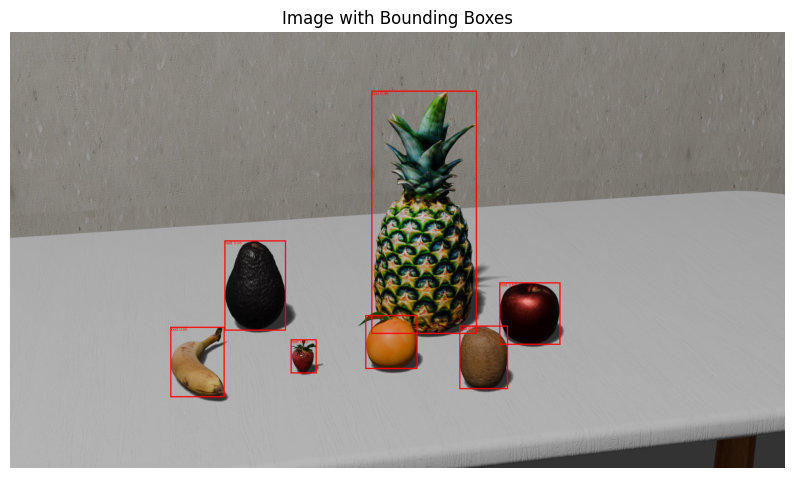

Coordinate (473, 867) is inside the bounding box tensor([397.2128, 730.0151, 531.9512, 904.4347], device='cuda:0'): (label: banana)


In [4]:
clicked_obj = pipeline.get_clicked_obj(img_path)

In [ ]:
pipeline.provide_explanation(clicked_obj, llm_model="qwen2.5:72b")

In [5]:
import src.entity_linking_lab.utils.cutting_queries as cutting
verb = "cut:Quartering"
steps = cutting.build_motion_table(clicked_obj[0], verb)


For cut:Quartering on FOODON_00003523, the prior task is: Halving, and the cutting tool is: Knife, and the cutting position is: HalvingPosition, and the repetition is: exactly 1
Remove peel: False, Remove core: False, Remove stem: False, Remove shell: True
Peeling tool: Nutcracker


,#,Motions,Inference
0,1,Peeling using a peeling tool,"has peel = true<br>peeling tool = ('Hand',)"
1,2,"Execute a prior task: ('Halving',)",has prior task = true<br>prior task = ('Halvin...
2,3,Picking up the cutting tool by ...,"cutting tool = ('Knife',)"
3,3a,... approaching the cutting tool,"cutting tool = ('Knife',)"
4,3b,... grasping the cutting tool,"cutting tool = ('Knife',)"
5,3c,... lifting the cutting tool,"cutting tool = ('Knife',)"
6,4,Cutting the target object at the position n ti...,target object = obo.FOODON_00004183 cut:Quarte...
7,4a,... approaching the target object at the position,target object = obo.FOODON_00004183 cut:Quarte...
8,4b,... lowering the cutting tool through the targ...,"cutting tool = ('Knife',)<br>target object = o..."
9,4c,... lifting the cutting tool,"cutting tool = ('Knife',)"
